# 04 — CHIRPS v3 climate raster in GeoLibre

**[🚀 Launch this notebook live](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=04_chirps_climate.ipynb)**

This lab visualizes a fixed daily **CHIRPS v3 RNL** precipitation Cloud-Optimized GeoTIFF from the WFP mirror on Source Cooperative. A fixed historical date makes the example reproducible while still demonstrating a collection that extends to near-present.

**Source clarification:** CHIRPS is a Climate Hazards Center (UC Santa Barbara) product, **not a NOAA product**.

> **JupyterLite compatibility:** this notebook uses `geolibre_lite.LiteMap`, which builds native GeoLibre project/layer definitions and displays them through GeoLibre's hosted `?embed=1` viewer. It deliberately avoids `geolibre.Map`, whose localhost HTTP server cannot bind a socket inside Pyodide/WebAssembly.


## See the connections

![Rainfall: separate weather from climate: Source: CHIRPS is produced by the Climate Hazards Center; Time: Daily totals and rolling sums differ; Baseline: An anomaly needs a comparable reference; Check: Synthetic practice is not extracted CHIRPS data](assets/04_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("geolibre==3.0.0")
from geolibre_lite import LiteMap as Map


In [2]:
CHIRPS = (
    "https://data.source.coop/wfp/chirps-rnl-daily/"
    "v3.0/2024/01/15/chirps-v3.0.rnl.2024.01.15.tif"
)

m = Map(center=(41.5, 5.0), zoom=4, height="720px")
m.add_cog(
    CHIRPS,
    name="CHIRPS v3 RNL — 2024-01-15",
    colormap="turbo",
    rescale=[0, 75],
)
m


## Analysis ideas

- Compare several daily COGs and calculate rolling rainfall totals.
- Join precipitation summaries to administrative areas or H3 cells.
- Train an anomaly model against a long-term baseline.
- Combine rainfall with WorldPop to estimate population exposed to dry/wet extremes.
- Add a separate NOAA HRRR/GFS notebook for forecast data while preserving distinct provenance.

GeoLibre's processing toolbox can be used interactively for raster inspection; for more intensive time-series cube processing, hand the collection to a full Python environment.


## Data & software citations

- Climate Hazards Center CHIRPS3 Data Repository (2025): https://doi.org/10.15780/G2JQ0P
- WFP CHIRPS v3 RNL daily COG mirror: https://source.coop/wfp/chirps-rnl-daily
- Mirror license: CC BY 4.0; attribution to the Climate Hazards Center is required.
- Peer-reviewed reference listed by the mirror: Funk et al. (2026), *Scientific Data*, https://doi.org/10.1038/s41597-026-07096-4
- GeoLibre: https://geolibre.app/


In [3]:
from IPython.display import display
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage("matplotlib")

## Practice reading a rainfall time series

**Synthetic teaching data — not CHIRPS observations.** The COG above is real CHIRPS; the series below is invented so the temporal arithmetic can run without downloading a raster cube. A climatological anomaly would require a long-term, seasonally matched reference.

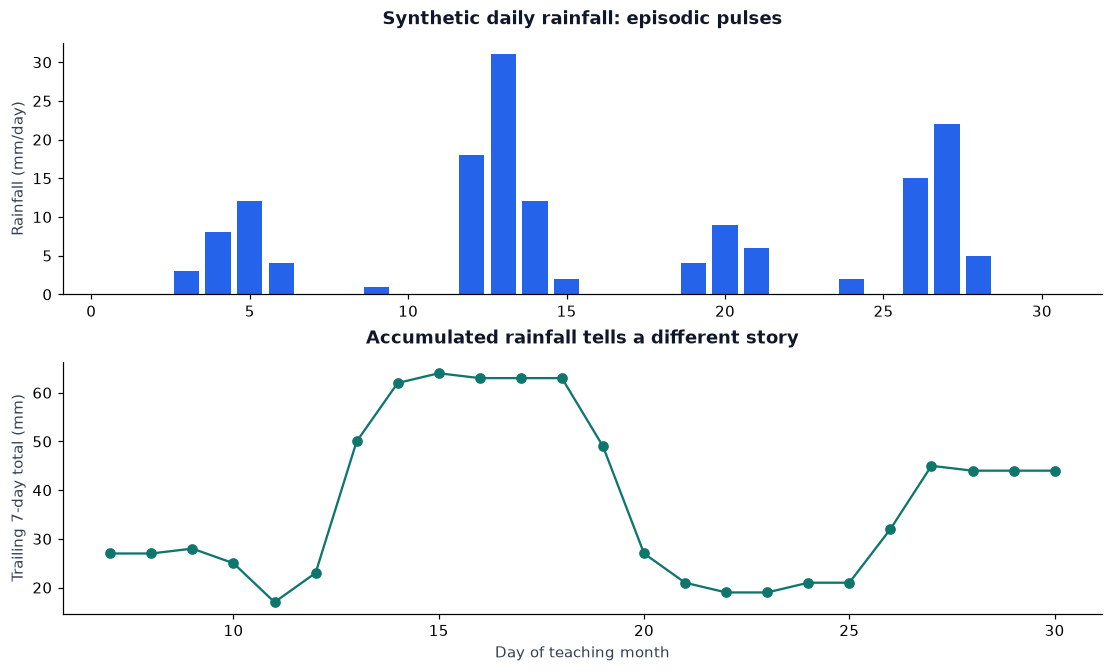

Invented monthly total (mm): 154.0


In [4]:
from cognition import style_plots
import numpy as np
import matplotlib.pyplot as plt
style_plots()
rain = np.array([0,0,3,8,12,4,0,0,1,0,0,18,31,12,2,0,0,0,4,9,6,0,0,2,0,15,22,5,0,0], dtype=float)
days = np.arange(1, len(rain)+1)
rolling = np.convolve(rain, np.ones(7), mode="valid")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), layout="constrained")
axes[0].bar(days, rain, color="#2563eb")
axes[0].set(ylabel="Rainfall (mm/day)", title="Synthetic daily rainfall: episodic pulses")
axes[1].plot(days[6:], rolling, "o-", color="#0f766e")
axes[1].set(xlabel="Day of teaching month", ylabel="Trailing 7-day total (mm)",
            title="Accumulated rainfall tells a different story")
plt.show()
print("Invented monthly total (mm):", rain.sum())

**Explain it:** why does a trailing seven-day total stay high after rainfall stops? Replace this fixture with spatially consistent CHIRPS samples in a full Python runtime, preserving nodata masks and rainfall units.